In [1]:
!export KAGGLE_API_TOKEN=KGAT_d83e8aba93d6b83fa32db05e574411be

In [2]:
!kaggle competitions list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aesika/english-premier-league-player-stats-2425")

print("Path to dataset files:", path)

100%|██████████| 32.5k/32.5k [00:00<00:00, 26.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aesika/english-premier-league-player-stats-2425/versions/4


In [4]:
import numpy as np
import pandas as pd
from scipy import stats

rng = np.random.default_rng(42)

In [5]:
df = pd.read_csv(path + "/epl_player_stats_24_25.csv")

In [6]:
df.iloc[:10]

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,...,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,...,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,...,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,...,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,...,9,1,0,0,0%,0,0,0,0,0.0
5,Gabriel Jesus,Arsenal,Brazil,FWD,17,603,3,0,20,0,...,14,4,0,0,0%,0,0,0,0,0.0
6,Gabriel Magalhães,Arsenal,Brazil,DEF,28,2365,3,1,22,25,...,19,4,0,0,0%,0,0,0,0,0.0
7,Gabriel Martinelli,Arsenal,Brazil,MID,33,2300,8,4,55,12,...,16,1,0,0,0%,0,0,0,0,0.0
8,Jakub Kiwior,Arsenal,Poland,DEF,17,1117,1,0,3,1,...,10,1,0,0,0%,0,0,0,0,0.0
9,Jorginho,Arsenal,Italy,MID,15,702,0,0,2,0,...,15,5,0,0,0%,0,0,0,0,0.0


In [7]:
# proceess df /MIN
mins = df['Minutes']

clustering_features = df.columns[6:]
features_permin = df[clustering_features].copy()

# TODO: remove players under X mins threshold

# convert str% to floats
percentage_features = features_permin.filter(like='%', axis=1).columns
for col in features_permin.columns:
    if col in percentage_features:
        features_permin[col] = features_permin[col].astype(str).str.strip('%').astype(float) / 100
    else:
        features_permin[col] = features_permin[col] / mins


# scale features to 0 mean, 1 std
for col in features_permin.columns:
    mean = features_permin[col].mean()
    std = features_permin[col].std()
    features_permin[col] = (features_permin[col] - mean) / std


In [8]:
# proceess df
clustering_features = df.columns[6:]
features = df[clustering_features].copy()

# convert str% to floats
percentage_features = features.filter(like='%', axis=1).columns
for col in percentage_features:
    features[col] = features[col].astype(str).str.strip('%').astype(float) / 100


# scale features to 0 mean, 1 std
for col in features.columns:
    mean = features[col].mean()
    std = features[col].std()
    features[col] = (features[col] - mean) / std


In [9]:
def initializeCentroidsPlusPlus(dataset, numFeatures, k):
    n = dataset.shape[0]
    rows = range(n)
    centroids = np.zeros((k, numFeatures))

    # first centroid random
    c1_idx = 2 #rng.choice(rows)
    c1 = dataset.iloc[c1_idx].to_numpy()
    centroids[0] = c1

    for i in range(1,k):
        # compute squared dists
        squared_ds = []
        for p in rows:
            min_squared_d = 2**7.5 # arbitrary max dist initial
            for c in centroids:
                if np.sum((dataset.iloc[p] - c)**2) < min_squared_d:
                    min_squared_d = np.sum((dataset.iloc[p] - c)**2)
            squared_ds.append(min_squared_d)

        # pick new centroid probabilistically
        weights = squared_ds / sum(squared_ds)
        c_new_idx = rng.choice(rows, p=weights)
        c_new = dataset.iloc[c_new_idx].to_numpy()

        centroids[i] = c_new

    return centroids

In [10]:
def getRandomCentroids(numFeatures, k):
    return rng.uniform(low=-1.0, high=1.0, size=(k, numFeatures))

In [11]:
# Returns a label for each piece of data in the dataset.
def getLabels(dataset, centroids):
    """
    For each element in the dataset, chose the closest centroid.
    Make that centroid the element's label
    """
    k = len(centroids)
    keys = range(k)
    labelDict = {k: [] for k in keys}
    #labels = np.zeros(dataset.shape[0])
    for idx in range(dataset.shape[0]):
        dists = np.zeros(k)
        for i, centroid in enumerate(centroids):
            dists[i] = np.sum((centroid - dataset.iloc[idx])**2, axis=0)
        min_dist = np.argmin(dists, axis=0)
        labelDict[min_dist].append(idx)
    return labelDict

In [12]:
# Returns k centroids, each of dimension numFeatures.
def getCentroids(dataset, labels, numFeatures, k):
    """
    Each centroid is the geometric mean of the points that
    have that centroid's label. Important: If a centroid is empty (no points have
    that centroid's label) you should randomly re-initialize it.
    """
    centroids = np.zeros((k, numFeatures))
    for idx, pointsIdx in labels.items():
        points = dataset.iloc[pointsIdx]
        if len(points) == 0:
            centroids[idx] = rng.uniform(low=-1.0, high=1.0, size=(numFeatures,))
        #centroids[idx] = stats.gmean(points, axis=0)
        else:
            centroids[idx] = np.mean(points, axis=0)
    return centroids

In [13]:
def kMeans(dataset, k, iterations=10):
    numFeatures = dataset.shape[1] # 6 to 56 considered
    centroids = initializeCentroidsPlusPlus(dataset, numFeatures, k)

    allCentroids = []

    for _ in range(iterations):
        allCentroids.append(centroids)
        print(centroids.shape)

        labels = getLabels(dataset, centroids)
        print(labels.items())

        centroids = getCentroids(dataset, labels, numFeatures, k)

    return centroids, allCentroids

In [14]:
centroids, allCentroids = kMeans(features_permin, 15, iterations=10)

(15, 51)
dict_items([(0, [2, 32, 67, 96, 112, 160, 176, 210, 223, 245, 247, 286, 293, 307, 358, 364, 408, 424, 437, 475, 484, 504, 544]), (1, [61, 116, 179, 288, 368, 400, 430, 443, 491]), (2, [4, 5, 9, 12, 17, 19, 20, 22, 26, 27, 29, 30, 31, 36, 38, 39, 42, 49, 53, 55, 57, 60, 63, 64, 65, 69, 70, 74, 76, 77, 80, 81, 85, 86, 87, 89, 90, 93, 97, 98, 101, 102, 103, 108, 109, 110, 111, 113, 114, 117, 118, 119, 121, 126, 135, 136, 139, 145, 146, 147, 151, 152, 154, 159, 161, 162, 165, 168, 169, 170, 171, 172, 182, 183, 185, 187, 189, 190, 195, 198, 212, 214, 215, 216, 225, 230, 232, 233, 235, 237, 239, 243, 244, 249, 253, 254, 256, 257, 258, 260, 262, 269, 270, 271, 275, 277, 283, 285, 290, 291, 294, 295, 296, 298, 299, 303, 305, 311, 316, 317, 319, 320, 321, 322, 329, 330, 332, 333, 337, 338, 339, 341, 348, 349, 350, 352, 355, 359, 365, 366, 369, 372, 374, 381, 384, 386, 387, 388, 389, 390, 394, 396, 404, 406, 407, 410, 411, 413, 418, 420, 421, 422, 423, 425, 428, 433, 435, 436, 438, 439,

In [15]:
import matplotlib.pyplot as plt

movements = []
allCentroidsArray = np.array(allCentroids)
for i in range(allCentroidsArray.shape[0]-1):
    dists = []
    for centroid in range(15):
        dists.append(np.sqrt(np.sum((allCentroidsArray[i+1, centroid] - allCentroidsArray[i, centroid])**2)))
    movements.append(dists)

movements = np.array(movements)


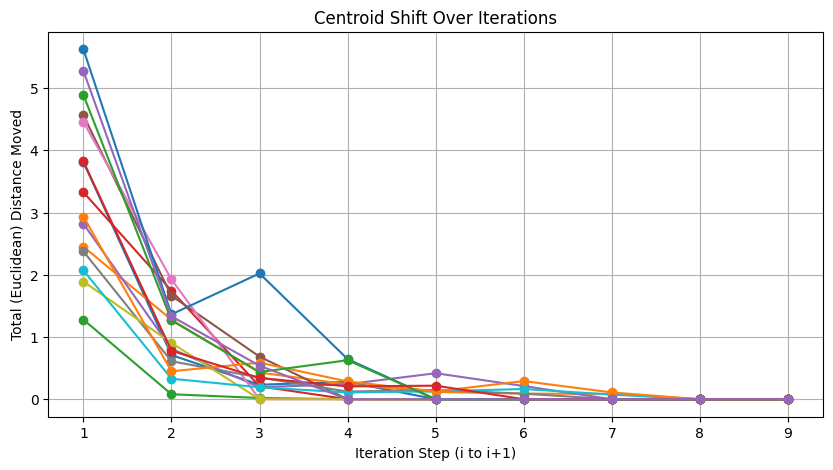

In [16]:
# plot
plt.figure(figsize=(10, 5))

for c in range(15):
    plt.plot(range(1, len(movements) + 1), movements[:, c], marker='o', linestyle='-')
plt.title('Centroid Shift Over Iterations')
plt.xlabel('Iteration Step (i to i+1)')
plt.ylabel('Total (Euclidean) Distance Moved')
plt.grid(True)
plt.show()

In [17]:
test_label = getLabels(features_permin, centroids)

In [18]:
cluster_density = np.zeros(15)
for k, val in test_label.items():
    cluster_density[k] = len(val)

In [19]:
df.iloc[test_label[13]]

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
16,Myles Lewis-Skelly,Arsenal,England,DEF,23,1370,1,0,3,6,...,11,3,2,0,0%,0,0,0,0,0.0
34,Ian Maatsen,Aston Villa,Netherlands,DEF,29,1128,1,2,19,4,...,11,2,0,0,0%,0,0,0,0,0.0
58,David Brooks,Bournemouth,Wales,MID,29,949,2,0,25,4,...,11,3,0,0,0%,0,0,0,0,0.0
116,Danny Welbeck,Brighton & Hove Albion,England,FWD,30,2122,10,0,60,2,...,11,5,0,0,0%,0,0,0,0,0.0
131,Mats Wieffer,Brighton & Hove Albion,Netherlands,MID,25,1008,1,0,9,3,...,23,6,0,0,0%,0,0,0,0,0.0
132,Matt O'Riley,Brighton & Hove Albion,Denmark,MID,21,937,2,0,22,10,...,16,1,0,0,0%,0,0,0,0,0.0
163,Tosin Adarabioyo,Chelsea,England,DEF,22,1404,1,1,13,3,...,8,4,0,0,0%,0,0,0,0,0.0
166,Wesley Fofana,Chelsea,France,DEF,14,1176,0,0,3,8,...,24,7,0,0,0%,0,0,0,0,0.0
174,Daichi Kamada,Crystal Palace,Japan,MID,34,1553,0,0,20,7,...,28,4,1,0,0%,0,0,0,0,0.0
289,Jannik Vestergaard,Leicester City,Denmark,DEF,18,1395,0,0,3,3,...,12,5,0,0,0%,0,1,0,0,0.0


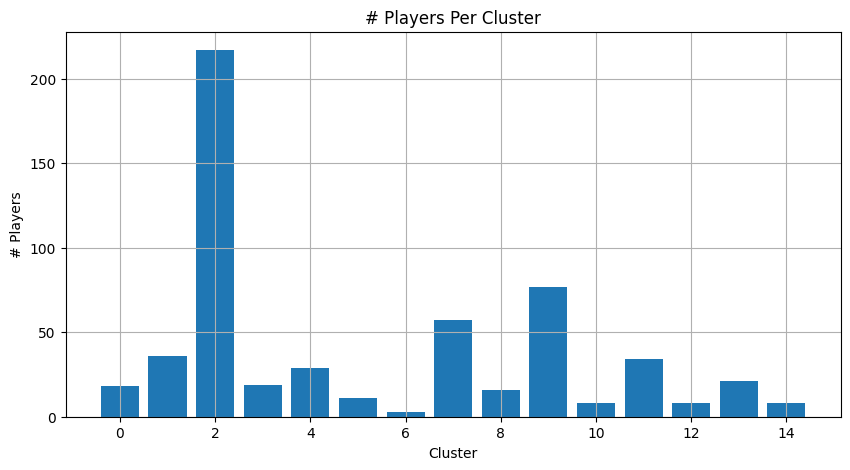

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(range(15), cluster_density)

plt.title('# Players Per Cluster')
plt.xlabel('Cluster')
plt.ylabel('# Players')
plt.grid(True)
plt.show()

Changes:
- Better initialization than random : KMeans ++
- Lower dimensions??: PCA

UPDATE:
- Implemented Kmean++, data still not spread out, majority of points in first 2-3 clusters, but groups look better
- Made all stats /min or /appearance, even better
- Issues: One or two clusters taking way too many players while other clusters have close to 0



Linear Regression:

X: Stats

Y: (Win% With)/ (Win% Without) [Basically +/-]

--> Rank players based on expected contribution to team

In [21]:
path1 = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")

print("Path to dataset files:", path1)

100%|██████████| 28.0M/28.0M [00:00<00:00, 162MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/versions/4


In [22]:
fifa_ratings_df = pd.read_csv(path1 + '/male_players.csv')

/tmp/ipykernel_12946/793308744.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa_ratings_df = pd.read_csv(path1 + '/male_players.csv')


In [23]:
fifa_ratings_df.iloc[:10]

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,...,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,...,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,...,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,...,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,19+3
4,165153,/player/165153/karim-benzema/240002,24.0,2.0,2023-09-22,K. Benzema,Karim Benzema,"CF, ST",90,90,...,64+3,64+3,64+3,64+3,60+3,55+3,55+3,55+3,60+3,18+3
5,188545,/player/188545/robert-lewandowski/240002,24.0,2.0,2023-09-22,R. Lewandowski,Robert Lewandowski,ST,90,90,...,66+3,66+3,66+3,65+3,61+3,61+3,61+3,61+3,61+3,19+3
6,192119,/player/192119/thibaut-courtois/240002,24.0,2.0,2023-09-22,T. Courtois,Thibaut Nicolas Marc Courtois,GK,90,90,...,31+3,31+3,31+3,29+3,29+3,29+3,29+3,29+3,29+3,88+2
7,202126,/player/202126/harry-kane/240002,24.0,2.0,2023-09-22,H. Kane,Harry Kane,ST,90,90,...,69+3,69+3,69+3,67+3,64+3,63+3,63+3,63+3,64+3,20+3
8,238794,/player/238794/vinicius-jose-de-oliveira-junio...,24.0,2.0,2023-09-22,Vini Jr.,Vinícius José Paixão de Oliveira Júnior,LW,89,94,...,58+3,58+3,58+3,62+3,57+3,45+3,45+3,45+3,57+3,16+3
9,212831,/player/212831/alisson-ramses-becker/240002,24.0,2.0,2023-09-22,Alisson,Alisson Ramsés Becker,GK,89,90,...,39+3,39+3,39+3,34+3,33+3,33+3,33+3,33+3,33+3,87+3


In [24]:
fifa_ratings_df.groupby(['short_name', 'fifa_version'])['overall'].mean().sort_values()

short_name         fifa_version
T. Davies          15.0            40.0
P. Tisdale         15.0            40.0
P. Żemło           15.0            40.0
E. Redman          15.0            41.0
L. Pilling         15.0            42.0
                                   ... 
L. Messi           16.0            94.0
Cristiano Ronaldo  17.0            94.0
                   18.0            94.0
L. Messi           20.0            94.0
                   19.0            94.0
Name: overall, Length: 170373, dtype: float64

In [25]:
def ridge_regression(X, Y, alpha=0.01):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    identity_matrix = np.eye(X_b.shape[1])
    identity_matrix[0, 0] = 0

    weights = np.linalg.inv(X_b.T @ X_b + alpha * identity_matrix) @ X_b.T @ Y
    return weights

In [26]:
# new df, market value:
path = kagglehub.dataset_download("berkayyce/football-player-performance-and-personal-data")

print("Path to dataset files:", path)

100%|██████████| 205k/205k [00:00<00:00, 43.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/berkayyce/football-player-performance-and-personal-data/versions/1


In [27]:
mv_df = pd.read_csv(path + "/dataset.csv")

# rename columns to english
rename_dict = {
    'Oyuncu': 'Player', 'Yaş': 'Age', 'Uyruk': 'Nationality', 'Mevki': 'Position',
    'Sezon': 'Season', 'Lig': 'League', 'Kategori': 'Category', 'MP': 'MP',
    'DK': 'Min', 'GLS': 'G', 'AST': 'A', 'ASR': 'Average Season Rating', 'TOS': 'Shots',
    'SOT': 'SoT', 'BCM': 'BCM', 'KEYP': 'KP', 'BCC': 'BCC', 'SDR': 'SDR',
    'APS': 'AccPasses', 'APS%': 'Pass%', 'ALB': 'LongBalls', 'LBA%': 'LongBall%',
    'ACR': 'Crosses', 'CA%': 'Cross%', 'CLS': 'CleanSheets', 'YC': 'YC', 'RC': 'RC',
    'ELTG': 'DuelsLost', 'DRP': 'DribbledPast', 'TACK': 'Tkl', 'INT': 'Int',
    'BLS': 'Blocks', 'ADW': 'AerialWon', 'xG': 'xG', 'xA': 'xA', 'GI': 'GI',
    'XGI': 'xGI', 'Bonservis': 'MarketValue'
}

mv_df.rename(columns=rename_dict, inplace=True)
mv_df['MarketValue'] = pd.to_numeric(mv_df['MarketValue'].astype(str).str.replace('.', ''))

test_df = mv_df[(mv_df['League']=='Premier League')  & (mv_df['Season']=='21/22')]
train_df = mv_df[~((mv_df['League']=='Premier League')  & (mv_df['Season']=='21/22'))]

In [28]:
for col in mv_df.columns:
    print(f'# of Nan in {col}: ' + str(len(mv_df[col]) - mv_df[col].count()))

# of Nan in Player: 0
# of Nan in Age: 0
# of Nan in Nationality: 0
# of Nan in Position: 0
# of Nan in Season: 0
# of Nan in League: 0
# of Nan in Category: 0
# of Nan in MP: 0
# of Nan in Min: 0
# of Nan in G: 0
# of Nan in A: 0
# of Nan in Average Season Rating: 108
# of Nan in Shots: 457
# of Nan in SoT: 457
# of Nan in BCM: 0
# of Nan in KP: 0
# of Nan in BCC: 0
# of Nan in SDR: 0
# of Nan in AccPasses: 7
# of Nan in Pass%: 12
# of Nan in LongBalls: 244
# of Nan in LongBall%: 412
# of Nan in Crosses: 744
# of Nan in Cross%: 1689
# of Nan in CleanSheets: 0
# of Nan in YC: 0
# of Nan in RC: 0
# of Nan in DuelsLost: 0
# of Nan in DribbledPast: 0
# of Nan in Tkl: 0
# of Nan in Int: 0
# of Nan in Blocks: 457
# of Nan in AerialWon: 496
# of Nan in xG: 3070
# of Nan in xA: 2982
# of Nan in GI: 1
# of Nan in xGI: 2981
# of Nan in MarketValue: 0


In [29]:
columns_to_drop = ['Player', 'Nationality', 'Position', 'Season', 'League', 'Category', 'MP', 'Shots', 'SoT', 'Blocks', 'Crosses', 'Cross%', 'AerialWon', 'Average Season Rating', 'LongBalls', 'LongBall%', 'xG', 'xA', 'xGI']

features_train_df = train_df.drop(columns=columns_to_drop)
features_test_df = test_df.drop(columns=columns_to_drop)

# drop rows with Nan
for row in range(mv_df.shape[0]):
  for item in mv_df.columns:
      features_train_df = features_train_df.dropna()
      features_test_df = features_test_df.dropna()

In [30]:
features_train_df.shape, features_test_df.shape

((4629, 19), (192, 19))

In [31]:
def ridge_regression(X, Y, alpha=0.1):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    identity_matrix = np.eye(X_b.shape[1])
    identity_matrix[0, 0] = 0

    weights = np.linalg.inv(X_b.T @ X_b + alpha * identity_matrix) @ X_b.T @ Y
    return weights

def nmse(Y, Y_hat):
    error = 0
    for y, y_hat in zip(Y, Y_hat):
        error = error + (y - y_hat)**2
    return np.sqrt(error / len(Y))

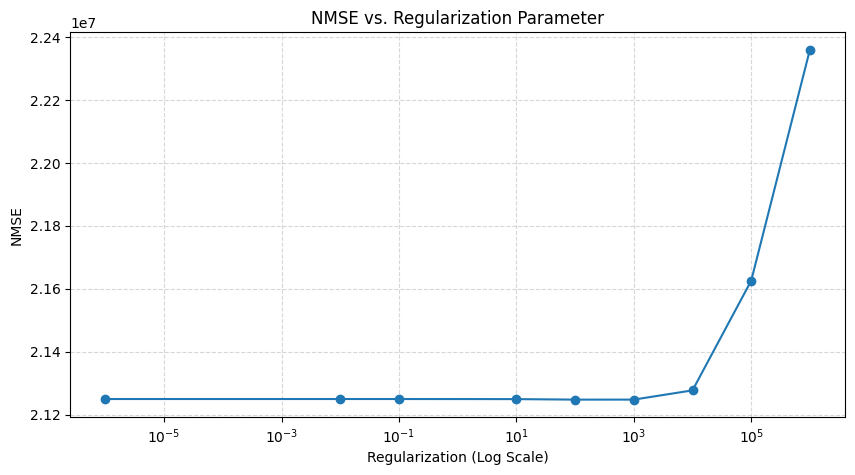

Alpha: 1e-06      | NMSE: 21,249,801.37
Alpha: 0.01       | NMSE: 21,249,816.86
Alpha: 0.1        | NMSE: 21,249,814.17
Alpha: 10         | NMSE: 21,249,532.15
Alpha: 100        | NMSE: 21,247,914.65
Alpha: 1000       | NMSE: 21,247,958.28
Alpha: 10000      | NMSE: 21,277,316.16
Alpha: 100000     | NMSE: 21,625,618.01
Alpha: 1000000    | NMSE: 22,359,417.99


In [48]:
# cross validation
errors = []
alphas = [1e-6, 1e-2, 1e-1, 10, 100, 1000, 10000, 100000, 1000000]
k = 10
n = features_train_df.shape[0]

shuffled_idx = np.arange(n)
rng.shuffle(shuffled_idx)
folds = np.arange(0, n, n//k)

for a in alphas:
    error = 0
    for i in range(k):
        val_idx = shuffled_idx[folds[i]:folds[i+1]]
        train_idx = np.setdiff1d(shuffled_idx, val_idx)

        X_train = features_train_df[features_train_df.columns[:-1]].to_numpy()[train_idx]
        Y_train = features_train_df[features_train_df.columns[-1]].to_numpy()[train_idx]

        X_val = features_train_df[features_train_df.columns[:-1]].to_numpy()[val_idx]
        Y_val = features_train_df[features_train_df.columns[-1]].to_numpy()[val_idx]

        X_val_with_intercept = np.c_[np.ones((X_val.shape[0], 1)), X_val]
        # train
        W = ridge_regression(X_train, Y_train, alpha=a)
        Y_pred = X_val_with_intercept @ W

        error = error + nmse(Y_val, Y_pred)
    error = error / k
    errors.append(error)

plt.figure(figsize=(10, 5))
plt.plot(alphas, errors, marker='o')
plt.xscale('log')
plt.title('NMSE vs. Regularization Parameter')
plt.xlabel('Regularization (Log Scale)')
plt.ylabel('NMSE')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

for a, e in zip(alphas, errors):
    print(f'Alpha: {a:<10} | NMSE: {e:,.2f}')

In [49]:
# inference
X_test = features_test_df[features_train_df.columns[:-1]].to_numpy()
Y_test = features_test_df[features_train_df.columns[-1]].to_numpy()
X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]

W = ridge_regression(X_train, Y_train)

Y_pred_test = X_test_with_intercept @ W


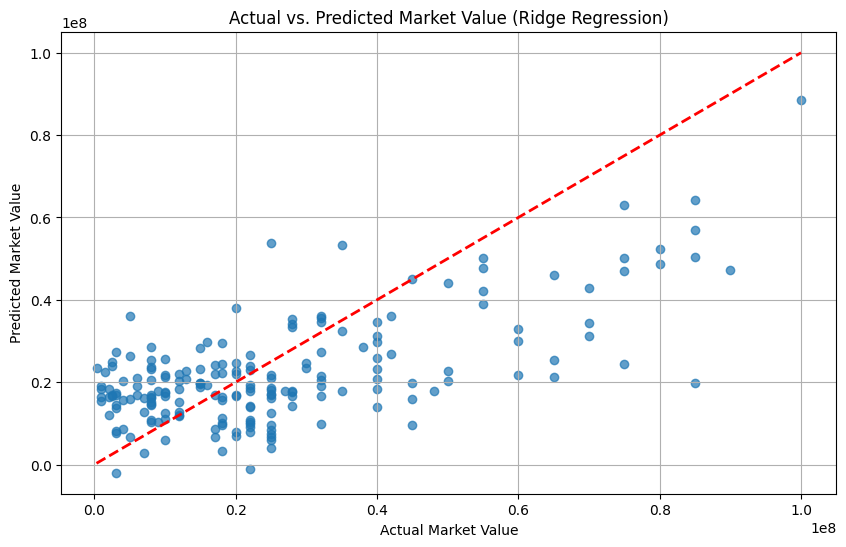

16692918.578769164


In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_test, alpha=0.7)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--', linewidth=2) # Perfect prediction line
plt.title('Actual vs. Predicted Market Value (Ridge Regression)')
plt.xlabel('Actual Market Value')
plt.ylabel('Predicted Market Value')
plt.grid(True)
plt.show()

print(nmse(Y_test, Y_pred_test))

In [35]:
test_df

,Player,Age,Nationality,Position,Season,League,Category,MP,Min,G,...,DribbledPast,Tkl,Int,Blocks,AerialWon,xG,xA,GI,xGI,MarketValue
3,Aaron Cresswell,32,ENG,D,21/22,Premier League,Domestic leagues,31,2728,2,...,12,28,35,7.0,32.0,NaN,NaN,5.0,NaN,2500000
16,Aaron Wan Bissaka,24,ENG,D,21/22,Premier League,Domestic leagues,20,1794,0,...,6,49,34,3.0,19.0,NaN,NaN,0.0,NaN,18000000
32,Abdoulaye Doucoure,28,MLI,OS,21/22,Premier League,Domestic leagues,30,2544,2,...,39,75,28,13.0,35.0,NaN,NaN,6.0,NaN,25000000
57,Adam Lallana,33,ENG,OS,21/22,Premier League,Domestic leagues,24,1574,0,...,29,34,16,5.0,15.0,NaN,NaN,1.0,NaN,2500000
81,Adam Webster,26,ENG,D,21/22,Premier League,Domestic leagues,22,1438,2,...,7,26,17,1.0,56.0,NaN,NaN,2.0,NaN,18000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4699,Williams Neco,20,WAL,D,21/22,Premier League,Domestic leagues,1,9,0,...,0,0,0,NaN,NaN,NaN,NaN,1.0,NaN,8000000
4728,Willy Boly,30,CIV,D,21/22,Premier League,Domestic leagues,10,900,0,...,7,25,14,0.0,20.0,NaN,NaN,0.0,NaN,8000000
4777,Yoane Wissa,25,COD,F,21/22,Premier League,Domestic leagues,30,1285,7,...,15,12,8,6.0,20.0,NaN,NaN,8.0,NaN,12000000
4786,Youri Tielemans,24,BEL,OS,21/22,Premier League,Domestic leagues,32,2633,6,...,58,74,21,20.0,24.0,NaN,NaN,10.0,NaN,55000000


In [36]:
Y_pred_test.astype(int)

array([24760090,  9305227, 17955751, 25263761, 24716959, 16742220,
       18206486, 14829730, 26019219, 46517917, 19053818,  7096995,
       19209970, 28294058, 24712993,  8232800,  8150400, 16716729,
       17762693, 34168428, 51158146, 14146106, 50441391, 29720984,
        9010523, 25148566, 21363497, 16997277, 22901461, -1766132,
        5190508, 28982724, 22726509, 20730279, 13460937, 21415600,
       17265715, 13125114, 21916603, 27204237, 24172636, 32492161,
       16831469, 11470834, 45043604, 16210098,  1462774, 19632934,
       21785037,  7155209, 30100602, 10882495, 16482317,  9457327,
       13238921, 42711862, 34415094, 21304053,  9620323, 18074181,
       24285133, 35246906, 17703943, 19774668, 60536413, 23779305,
       52864760, 17255283, 20313119, 30595688, 11957741, 14999547,
        8849078, 22631695,  3501805, 17611523, 16631258, 42031187,
       15963239, 28251750,    56834, 35766336, 35439689,  9127751,
       23072146, 14061050, 34268925, 17413667, 27244755, 15363

In [37]:
df_all = test_df.merge(features_test_df.drop_duplicates(), how='left', indicator=True)

# find row that got dropped in features df
test_df_only = df_all[df_all['_merge'] == 'left_only'].drop(columns=['_merge'])

test_df = test_df.drop(test_df.index[test_df_only.index])

In [38]:
test_df['Predicted_Market_Value'] = Y_pred_test.astype(int)

In [39]:
test_df['Market_Value_Residual'] = test_df['MarketValue'] - test_df['Predicted_Market_Value']

In [40]:
test_df

,Player,Age,Nationality,Position,Season,League,Category,MP,Min,G,...,Int,Blocks,AerialWon,xG,xA,GI,xGI,MarketValue,Predicted_Market_Value,Market_Value_Residual
3,Aaron Cresswell,32,ENG,D,21/22,Premier League,Domestic leagues,31,2728,2,...,35,7.0,32.0,NaN,NaN,5.0,NaN,2500000,24760090,-22260090
16,Aaron Wan Bissaka,24,ENG,D,21/22,Premier League,Domestic leagues,20,1794,0,...,34,3.0,19.0,NaN,NaN,0.0,NaN,18000000,9305227,8694773
32,Abdoulaye Doucoure,28,MLI,OS,21/22,Premier League,Domestic leagues,30,2544,2,...,28,13.0,35.0,NaN,NaN,6.0,NaN,25000000,17955751,7044249
57,Adam Lallana,33,ENG,OS,21/22,Premier League,Domestic leagues,24,1574,0,...,16,5.0,15.0,NaN,NaN,1.0,NaN,2500000,25263761,-22763761
81,Adam Webster,26,ENG,D,21/22,Premier League,Domestic leagues,22,1438,2,...,17,1.0,56.0,NaN,NaN,2.0,NaN,18000000,24716959,-6716959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4699,Williams Neco,20,WAL,D,21/22,Premier League,Domestic leagues,1,9,0,...,0,NaN,NaN,NaN,NaN,1.0,NaN,8000000,25260336,-17260336
4728,Willy Boly,30,CIV,D,21/22,Premier League,Domestic leagues,10,900,0,...,14,0.0,20.0,NaN,NaN,0.0,NaN,8000000,20855925,-12855925
4777,Yoane Wissa,25,COD,F,21/22,Premier League,Domestic leagues,30,1285,7,...,8,6.0,20.0,NaN,NaN,8.0,NaN,12000000,18015918,-6015918
4786,Youri Tielemans,24,BEL,OS,21/22,Premier League,Domestic leagues,32,2633,6,...,21,20.0,24.0,NaN,NaN,10.0,NaN,55000000,38101707,16898293


### Model Error Analysis
Analyzing the residuals (Actual - Predicted) helps identify patterns in the model's mistakes.

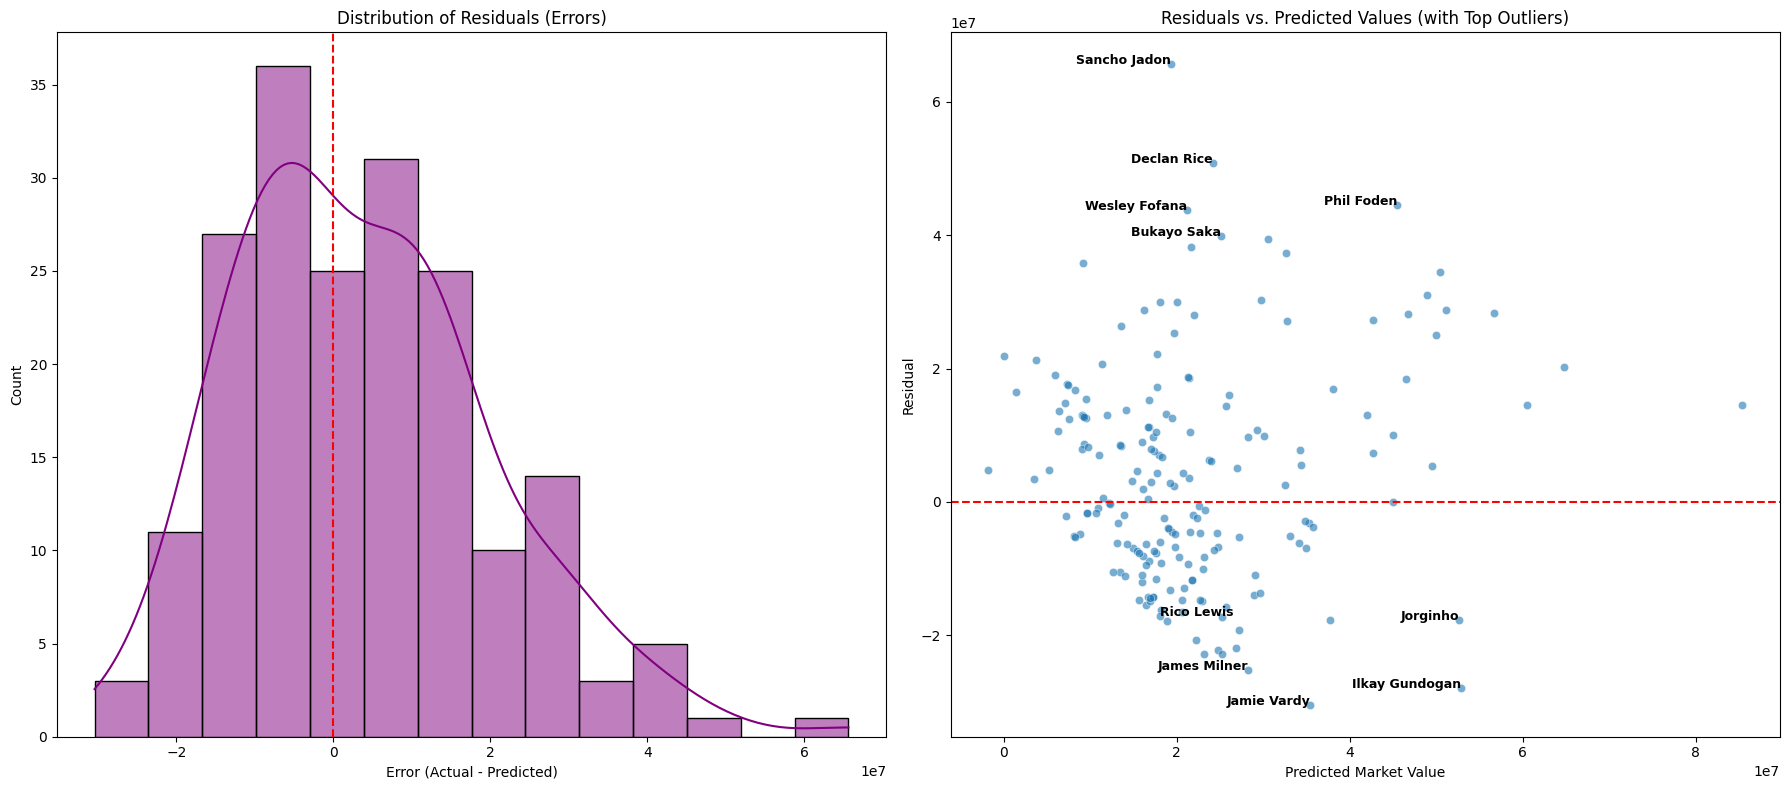

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# residuals
sns.histplot(test_df['Market_Value_Residual'], kde=True, ax=axes[0], color='purple')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Residuals (Errors)')
axes[0].set_xlabel('Error (Actual - Predicted)')

# residuals vs predicted
sns.scatterplot(data=test_df, x='Predicted_Market_Value', y='Market_Value_Residual', alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values (with Top Outliers)')
axes[1].set_xlabel('Predicted Market Value')
axes[1].set_ylabel('Residual')

# 5 most
undervalued = test_df.sort_values(by='Market_Value_Residual', ascending=False).head(5)
overvalued = test_df.sort_values(by='Market_Value_Residual', ascending=True).iloc[[0,1,2,10, 13]]

# labeling
for _, row in pd.concat([undervalued, overvalued]).iterrows():
    axes[1].text(
        row['Predicted_Market_Value'],
        row['Market_Value_Residual'],
        row['Player'],
        fontsize=9,
        fontweight='bold',
        ha='right' if row['Predicted_Market_Value'] > test_df['Predicted_Market_Value'].median() else 'left'
    )

plt.tight_layout()
plt.show()

#### Top 10 'Undervalued' Players
Players whose actual Market Value is much higher than what our stats-based model predicted.

In [42]:
display(test_df.sort_values(by='Market_Value_Residual', ascending=False)[['Player', 'MarketValue', 'Predicted_Market_Value', 'Market_Value_Residual']].head(10))

,Player,MarketValue,Predicted_Market_Value,Market_Value_Residual
4157,Sancho Jadon,85000000,19351923,65648077
1027,Declan Rice,75000000,24172636,50827364
3829,Phil Foden,90000000,45499900,44500100
4644,Wesley Fofana,65000000,21159156,43840844
590,Bukayo Saka,65000000,25148566,39851434
1867,Jack Grealish,70000000,30595688,39404312
3036,Marcus Rashford,60000000,21702725,38297275
2511,Kai Havertz,70000000,32590730,37409270
4425,Tomas Soucek,45000000,9146915,35853085
540,Bruno Fernandes,85000000,50441391,34558609


#### Top 10 'Overvalued' Players
Players whose stats suggest they should be worth much more than their actual market value (or where the model significantly over-predicted).

In [43]:
display(test_df.sort_values(by='Market_Value_Residual', ascending=True)[['Player', 'MarketValue', 'Predicted_Market_Value', 'Market_Value_Residual']].head(10))

,Player,MarketValue,Predicted_Market_Value,Market_Value_Residual
2053,Jamie Vardy,5000000,35439689,-30439689
1806,Ilkay Gundogan,25000000,52864760,-27864760
2012,James Milner,3000000,28251750,-25251750
2552,Kasey Mcateer,300000,23204366,-22904366
57,Adam Lallana,2500000,25263761,-22763761
3,Aaron Cresswell,2500000,24760090,-22260090
2342,Jonny Evans,5000000,26882329,-21882329
2824,Liam Delap,1500000,22235015,-20735015
956,Danny Welbeck,8000000,27204237,-19204237
4022,Romeo Lavia,1000000,18898171,-17898171


### Retraining with Log Transformation
We apply `np.log1p` to the target variable to handle the high variance in market values.

In [46]:
import numpy as np


X_train = features_train_df[features_train_df.columns[:-1]].to_numpy()
X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]


Y_train_log = np.log1p(features_train_df[features_train_df.columns[-1]].to_numpy())
Y_test_log = np.log1p(features_test_df[features_train_df.columns[-1]].to_numpy())

best_alpha = 0.1
W_log = ridge_regression(X_train, Y_train_log, alpha=best_alpha)

Y_pred_log = X_test_with_intercept @ W_log

test_df['Predicted_MV_LogModel'] = np.expm1(Y_pred_log)
test_df['Residual_LogModel'] = test_df['MarketValue'] - test_df['Predicted_MV_LogModel']

print(f"Log-Model RMSE (on original scale): {nmse(test_df['MarketValue'], test_df['Predicted_MV_LogModel']):,.2f}")

Log-Model RMSE (on original scale): 21,275,689.70


### Log-Model Error Analysis
We visualize the residuals of the log-transformed model to check if the high-variance (heteroscedasticity) issue has been mitigated.

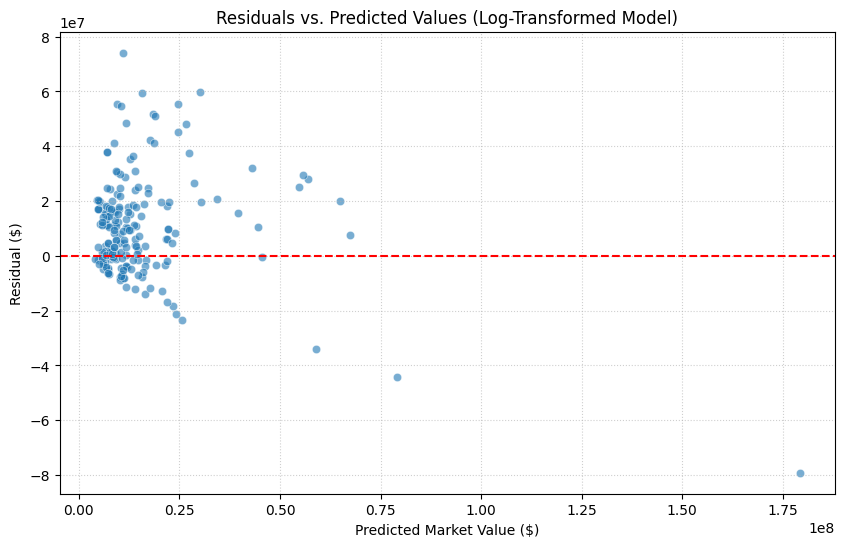

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='Predicted_MV_LogModel', y='Residual_LogModel', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values (Log-Transformed Model)')
plt.xlabel('Predicted Market Value ($)')
plt.ylabel('Residual ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Performance Comparison: Original vs. Log Scale
Comparing the Root Mean Squared Error (RMSE) to see which model generalizes better to the Premier League test set.

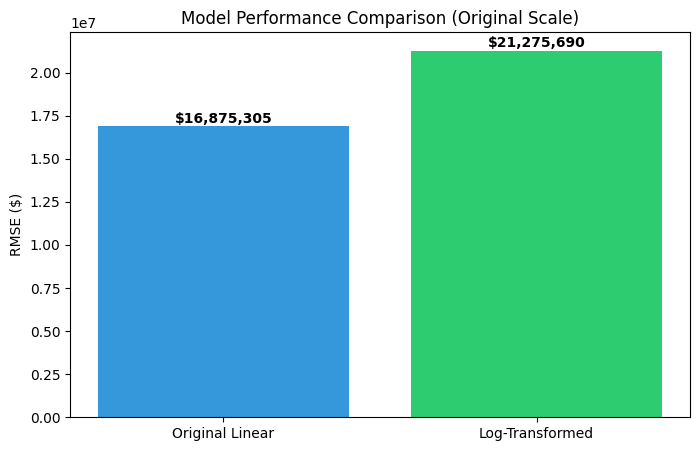

In [52]:
original_rmse = nmse(test_df['MarketValue'], test_df['Predicted_Market_Value'])
log_rmse = nmse(test_df['MarketValue'], test_df['Predicted_MV_LogModel'])

models = ['Original Linear', 'Log-Transformed']
values = [original_rmse, log_rmse]

plt.figure(figsize=(8, 5))
plt.bar(models, values, color=['#3498db', '#2ecc71'])
plt.ylabel('RMSE ($)')
plt.title('Model Performance Comparison (Original Scale)')
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.01), f'${v:,.0f}', ha='center', fontweight='bold')
plt.show()

### Feature Importance (Model Weights)
By plotting the weights assigned to each feature, we can see which statistics the model relies on most to predict valuation.

/tmp/ipykernel_12946/3963636587.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weights_df, x='Weight', y='Feature', palette='vlag')


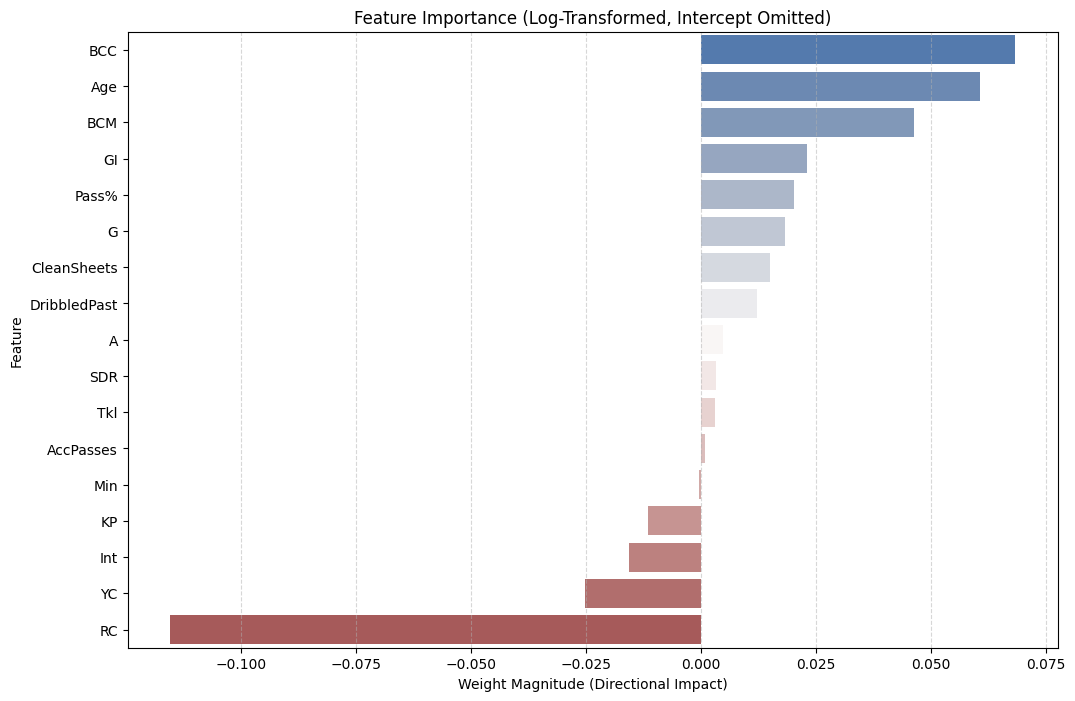

In [124]:
feature_names = ['Intercept'] + list(features_train_df.columns[:-1])
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': W_log.flatten()
})

weights_df['AbsWeight'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='Weight', ascending=False).drop([0, 14])

plt.figure(figsize=(12, 8))
sns.barplot(data=weights_df, x='Weight', y='Feature', palette='vlag')
plt.title('Feature Importance (Log-Transformed, Intercept Omitted)')
plt.xlabel('Weight Magnitude (Directional Impact)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Residual Statistics per Cluster
We map the K-Means cluster labels back to our Premier League test set to analyze performance geographically across player types.

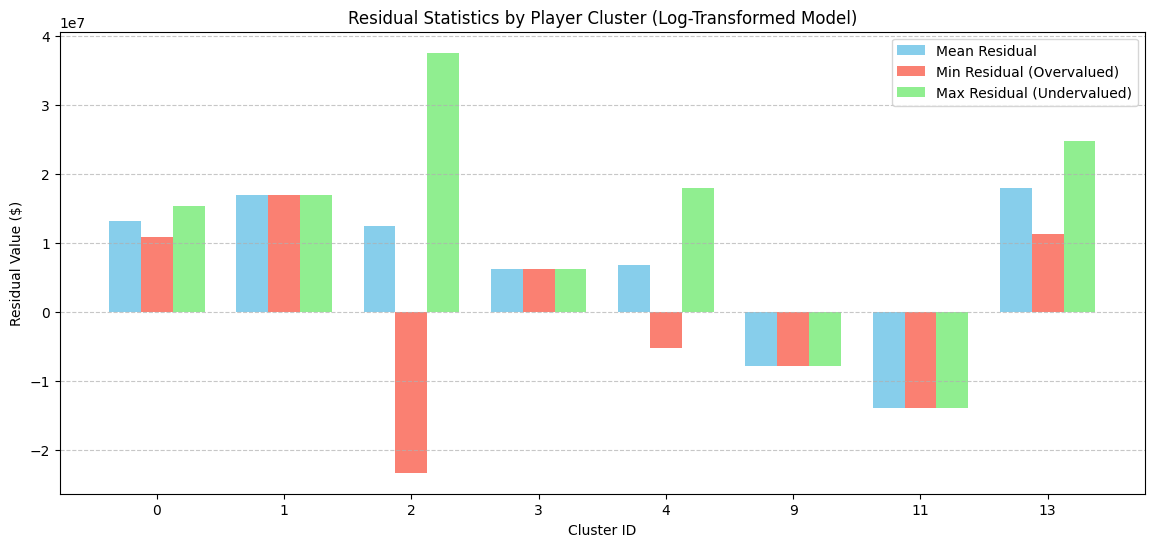

In [57]:
cluster_mapping = {}
for cluster_id, indices in test_label.items():
    for idx in indices:
        cluster_mapping[idx] = cluster_id

test_df['Cluster'] = test_df.index.map(cluster_mapping)

cluster_stats = test_df.groupby('Cluster')['Residual_LogModel'].agg(['mean', 'min', 'max']).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(cluster_stats['Cluster']))
width = 0.25

ax.bar(x - width, cluster_stats['mean'], width, label='Mean Residual', color='skyblue')
ax.bar(x, cluster_stats['min'], width, label='Min Residual (Overvalued)', color='salmon')
ax.bar(x + width, cluster_stats['max'], width, label='Max Residual (Undervalued)', color='lightgreen')

ax.set_xlabel('Cluster ID')
ax.set_ylabel('Residual Value ($)')
ax.set_title('Residual Statistics by Player Cluster (Log-Transformed Model)')
ax.set_xticks(x)
ax.set_xticklabels(cluster_stats['Cluster'].astype(int))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [58]:
import io
import pandas as pd

# Paste your raw text inside this triple-quoted string
raw_text = """
CLUSTER 0
Total Players: 59

Position Breakdown:
  DF: 46
  FW: 8
  MF: 15
Kieran Tierney            | Arsenal              | DF
Takehiro Tomiyasu         | Arsenal              | DF
Matt Targett              | Aston Villa          | DF
Ashley Young              | Aston Villa          | DF,FW
Ethan Pinnock             | Brentford            | DF
Rico Henry                | Brentford            | DF
Sergi Canós               | Brentford            | DF
Kristoffer Ajer           | Brentford            | DF
Mathias Jensen            | Brentford            | MF
Joel Veltman              | Brighton             | DF
Pascal Gross              | Brighton             | MF,DF
Jakub Moder               | Brighton             | FW,MF
Adam Lallana              | Brighton             | MF
Alexis Mac Allister       | Brighton             | MF,FW
Tariq Lamptey             | Brighton             | DF
Adam Webster              | Brighton             | DF
Solly March               | Brighton             | DF,FW
James Tarkowski           | Burnley              | DF
Charlie Taylor            | Burnley              | DF
Ben Mee                   | Burnley              | DF
Matthew Lowton            | Burnley              | DF
Jóhann Berg Guðmundsson   | Burnley              | MF
Marcos Alonso             | Chelsea              | DF
César Azpilicueta         | Chelsea              | DF
Séamus Coleman            | Everton              | DF
Ben Godfrey               | Everton              | DF
Mason Holgate             | Everton              | DF,MF
Lucas Digne               | Everton              | DF
Junior Firpo              | Leeds United         | DF
Robin Koch                | Leeds United         | MF,DF
Luke Thomas               | Leicester City       | DF
Kiernan Dewsbury Hall     | Leicester City       | MF
Timothy Castagne          | Leicester City       | DF
Aaron Wan-Bissaka         | Manchester United    | DF
Luke Shaw                 | Manchester United    | DF
Diogo Dalot               | Manchester United    | DF
Alex Telles               | Manchester United    | DF
Amad Diallo               | Manchester United    | FW
Andreas Pereira           | Manchester United    | MF
Fabian Schär              | Newcastle United     | DF
Jamaal Lascelles          | Newcastle United     | DF
Jonjo Shelvey             | Newcastle United     | MF
Ryan Fraser               | Newcastle United     | FW,MF
Javier Manquillo          | Newcastle United     | DF
Matt Ritchie              | Newcastle United     | DF
Miguel Almirón            | Newcastle United     | MF,FW
Jacob Murphy              | Newcastle United     | DF,FW
Emil Krafth               | Newcastle United     | DF
Mathias Normann           | Norwich City         | MF
Romain Perraud            | Southampton          | DF
Sergio Reguilón           | Tottenham            | DF
Kiko Femenía              | Watford              | DF
Imran Louza               | Watford              | MF
Hassane Kamara            | Watford              | DF
Vladimír Coufal           | West Ham United      | DF
Ben Johnson               | West Ham United      | DF
Nélson Semedo             | Wolves               | DF
Fernando Marçal           | Wolves               | DF
Rayan Aït Nouri           | Wolves               | DF

------------------------------------------------------------
CLUSTER 1
Total Players: 55

Position Breakdown:
  DF: 11
  FW: 3
  MF: 46
Thomas Partey             | Arsenal              | MF
Matty Cash                | Aston Villa          | DF
John McGinn               | Aston Villa          | MF
Douglas Luiz              | Aston Villa          | MF
Jacob Ramsey              | Aston Villa          | MF
Christian Nørgaard        | Brentford            | MF
Vitaly Janelt             | Brentford            | MF
Marc Cucurella            | Brighton             | DF
Dwight McNeil             | Burnley              | MF
Josh Brownhill            | Burnley              | MF
Ashley Westwood           | Burnley              | MF
Jorginho                  | Chelsea              | MF
N'Golo Kanté              | Chelsea              | MF
Mateo Kovačić             | Chelsea              | MF
Tyrick Mitchell           | Crystal Palace       | DF
Conor Gallagher           | Crystal Palace       | MF
Cheikhou Kouyaté          | Crystal Palace       | MF
Jeffrey Schlupp           | Crystal Palace       | MF,FW
James McArthur            | Crystal Palace       | MF
Allan                     | Everton              | MF
Abdoulaye Doucouré        | Everton              | MF
Stuart Dallas             | Leeds United         | DF,MF
Mateusz Klich             | Leeds United         | MF
Adam Forshaw              | Leeds United         | MF
Youri Tielemans           | Leicester City       | MF
Wilfred Ndidi             | Leicester City       | MF,DF
Fabinho                   | Liverpool            | MF
Thiago Alcántara          | Liverpool            | MF
Rodri                     | Manchester City      | MF
Scott McTominay           | Manchester United    | MF
Fred                      | Manchester United    | MF
Joelinton                 | Newcastle United     | MF,FW
Joe Willock               | Newcastle United     | MF
Sean Longstaff            | Newcastle United     | MF
Kenny McLean              | Norwich City         | MF
Max Aarons                | Norwich City         | DF
Brandon Williams          | Norwich City         | DF
Pierre Lees-Melou         | Norwich City         | MF
Billy Gilmour             | Norwich City         | MF
James Ward-Prowse         | Southampton          | MF
Oriol Romeu               | Southampton          | MF
Valentino Livramento      | Southampton          | DF
Kyle Walker-Peters        | Southampton          | DF
Pierre Højbjerg           | Tottenham            | MF
Emerson                   | Tottenham            | DF
Moussa Sissoko            | Watford              | MF
Juraj Kucka               | Watford              | MF
Tom Cleverley             | Watford              | MF
Declan Rice               | West Ham United      | MF
Tomáš Souček              | West Ham United      | MF
Aaron Cresswell           | West Ham United      | DF
João Moutinho             | Wolves               | MF
Rúben Neves               | Wolves               | MF
Hwang Hee-chan            | Wolves               | FW,MF
Leander Dendoncker        | Wolves               | MF

------------------------------------------------------------
CLUSTER 2
Total Players: 22

Position Breakdown:
  GK: 22
Aaron Ramsdale            | Arsenal              | GK
Emiliano Martínez         | Aston Villa          | GK
David Raya                | Brentford            | GK
Álvaro Fernández          | Brentford            | GK
Robert Sanchez            | Brighton             | GK
Nick Pope                 | Burnley              | GK
Edouard Mendy             | Chelsea              | GK
Vicente Guaita            | Crystal Palace       | GK
Jordan Pickford           | Everton              | GK
Illan Meslier             | Leeds United         | GK
Kasper Schmeichel         | Leicester City       | GK
Alisson                   | Liverpool            | GK
Ederson                   | Manchester City      | GK
David de Gea              | Manchester United    | GK
Martin Dúbravka           | Newcastle United     | GK
Tim Krul                  | Norwich City         | GK
Alex McCarthy             | Southampton          | GK
Fraser Forster            | Southampton          | GK
Hugo Lloris               | Tottenham            | GK
Ben Foster                | Watford              | GK
Łukasz Fabiański          | West Ham United      | GK
José Sá                   | Wolves               | GK

------------------------------------------------------------
CLUSTER 3
Total Players: 48

Position Breakdown:
  DF: 45
  MF: 4
Ben White                 | Arsenal              | DF
Gabriel Dos Santos        | Arsenal              | DF
Granit Xhaka              | Arsenal              | MF
Tyrone Mings              | Aston Villa          | DF
Ezri Konsa                | Aston Villa          | DF
Pontus Jansson            | Brentford            | DF
Lewis Dunk                | Brighton             | DF
Yves Bissouma             | Brighton             | MF
Shane Duffy               | Brighton             | DF
Antonio Rüdiger           | Chelsea              | DF
Thiago Silva              | Chelsea              | DF
Andreas Christensen       | Chelsea              | DF
Trevoh Chalobah           | Chelsea              | DF
Marc Guéhi                | Crystal Palace       | DF
Joachim Andersen          | Crystal Palace       | DF
Joel Ward                 | Crystal Palace       | DF
Michael Keane             | Everton              | DF
Luke Ayling               | Leeds United         | DF
Diego Llorente            | Leeds United         | DF
Pascal Struijk            | Leeds United         | DF,MF
Liam Cooper               | Leeds United         | DF
Çağlar Söyüncü            | Leicester City       | DF
Daniel Amartey            | Leicester City       | DF
Virgil van Dijk           | Liverpool            | DF
Joël Matip                | Liverpool            | DF
Aymeric Laporte           | Manchester City      | DF
Ruben Dias                | Manchester City      | DF
Kyle Walker               | Manchester City      | DF
Harry Maguire             | Manchester United    | DF
Victor Lindelöf           | Manchester United    | DF
Raphaël Varane            | Manchester United    | DF
Ben Gibson                | Norwich City         | DF
Grant Hanley              | Norwich City         | DF
Mohammed Salisu           | Southampton          | DF
Jan Bednarek              | Southampton          | DF
Eric Dier                 | Tottenham            | DF
Ben Davies                | Tottenham            | DF
Cristian Romero           | Tottenham            | DF
Oliver Skipp              | Tottenham            | MF
Davinson Sánchez          | Tottenham            | DF
Craig Cathcart            | Watford              | DF
William Troost-Ekong      | Watford              | DF
Samir Santos              | Watford              | DF
Craig Dawson              | West Ham United      | DF
Kurt Zouma                | West Ham United      | DF
Conor Coady               | Wolves               | DF
Max Kilman                | Wolves               | DF
Romain Saïss              | Wolves               | DF

------------------------------------------------------------
CLUSTER 4
Total Players: 46

Position Breakdown:
  FW: 42
  MF: 31
Alexandre Lacazette       | Arsenal              | FW,MF
Martinelli                | Arsenal              | FW,MF
Ollie Watkins             | Aston Villa          | FW
Danny Ings                | Aston Villa          | FW
Bryan Mbeumo              | Brentford            | FW,MF
Ivan Toney                | Brentford            | FW
Chris Wood                | Burnley              | FW
Maxwel Cornet             | Burnley              | FW,MF
Aaron Lennon              | Burnley              | MF
Jay Rodriguez             | Burnley              | FW
Romelu Lukaku             | Chelsea              | FW
Odsonne Édouard           | Crystal Palace       | FW
Christian Benteke         | Crystal Palace       | FW
Demarai Gray              | Everton              | MF,FW
Richarlison               | Everton              | FW,MF
Anthony Gordon            | Everton              | MF,FW
Andros Townsend           | Everton              | MF
Alex Iwobi                | Everton              | MF,FW
Jack Harrison             | Leeds United         | FW,MF
Daniel James              | Leeds United         | FW,MF
Rodrigo                   | Leeds United         | MF,FW
James Maddison            | Leicester City       | MF,FW
Harvey Barnes             | Leicester City       | FW,MF
Jamie Vardy               | Leicester City       | FW
Ademola Lookman           | Leicester City       | FW,MF
Mason Greenwood           | Manchester United    | FW,MF
Allan Saint-Maximin       | Newcastle United     | FW,MF
Callum Wilson             | Newcastle United     | FW
Teemu Pukki               | Norwich City         | FW
Milot Rashica             | Norwich City         | FW,MF
Josh Sargent              | Norwich City         | FW,MF
Che Adams                 | Southampton          | FW
Mohamed Elyounoussi       | Southampton          | MF
Armando Broja             | Southampton          | FW
Nathan Redmond            | Southampton          | MF,FW
Adam Armstrong            | Southampton          | FW,MF
Stuart Armstrong          | Southampton          | MF
Emmanuel Dennis           | Watford              | FW,MF
Joshua King               | Watford              | FW
Ismaila Sarr              | Watford              | FW,MF
Cucho                     | Watford              | FW,MF
João Pedro                | Watford              | FW,MF
Saïd Benrahma             | West Ham United      | FW,MF
Raúl Jiménez              | Wolves               | FW
Francisco Trincão         | Wolves               | FW,MF
Daniel Podence            | Wolves               | FW,MF

------------------------------------------------------------
CLUSTER 5
Total Players: 24

Position Breakdown:
  DF: 4
  FW: 15
  MF: 14
Martin Ødegaard           | Arsenal              | MF
Emile Smith Rowe          | Arsenal              | MF,FW
Emi Buendía               | Aston Villa          | FW,MF
Leandro Trossard          | Brighton             | FW,MF
Neal Maupay               | Brighton             | FW
Kai Havertz               | Chelsea              | FW,MF
Reece James               | Chelsea              | DF
Jordan Ayew               | Crystal Palace       | FW
Trent Alexander-Arnold    | Liverpool            | DF
Jordan Henderson          | Liverpool            | MF
Andrew Robertson          | Liverpool            | DF
Joao Cancelo              | Manchester City      | DF
Bernardo Silva            | Manchester City      | MF,FW
Phil Foden                | Manchester City      | FW
Kevin De Bruyne           | Manchester City      | MF
Jack Grealish             | Manchester City      | FW
Ilkay Gundogan            | Manchester City      | MF
Gabriel Jesus             | Manchester City      | FW
Riyad Mahrez              | Manchester City      | FW
Jadon Sancho              | Manchester United    | FW,MF
Paul Pogba                | Manchester United    | MF,FW
Lucas Moura               | Tottenham            | FW,MF
Pablo Fornals             | West Ham United      | FW,MF
Manuel Lanzini            | West Ham United      | MF

------------------------------------------------------------
CLUSTER 6
Total Players: 14

Position Breakdown:
  FW: 13
  MF: 5
Bukayo Saka               | Arsenal              | FW,MF
Mason Mount               | Chelsea              | MF,FW
Wilfried Zaha             | Crystal Palace       | FW
Raphael Dias Belloli      | Leeds United         | FW,MF
Mohamed Salah             | Liverpool            | FW
Sadio Mané                | Liverpool            | FW
Diogo Jota                | Liverpool            | FW
Raheem Sterling           | Manchester City      | FW
Bruno Fernandes           | Manchester United    | MF
Cristiano Ronaldo         | Manchester United    | FW
Harry Kane                | Tottenham            | FW
Son Heung-min             | Tottenham            | FW,MF
Michail Antonio           | West Ham United      | FW
Jarrod Bowen              | West Ham United      | FW
"""

players_data = []
current_cluster = None

# Process row by row
for line in io.StringIO(raw_text):
    line = line.strip()

    # Detect Cluster Groupings
    if line.startswith("CLUSTER"):
        current_cluster = line.split()[-1]
        continue

    # Skip formatting lines, totals, and blanks
    if (
        not line
        or line.startswith("-")
        or line.startswith("Total Players")
        or line.startswith("Position Breakdown")
        or ":" in line[:5]
    ):  # Catches things like 'DF: 46'
        continue

    # Parse player row split by pipe '|'
    if "|" in line:
        parts = [p.strip() for p in line.split("|")]
        if len(parts) >= 3:
            players_data.append(
                {
                    "Cluster": int(current_cluster),
                    "Player": parts[0],
                    "Team": parts[1],
                    "Position": parts[2],
                }
            )

# Create dataframe
df = pd.DataFrame(players_data)

# Show structure preview
print(df.head())

   Cluster             Player         Team Position
0        0     Kieran Tierney      Arsenal       DF
1        0  Takehiro Tomiyasu      Arsenal       DF
2        0       Matt Targett  Aston Villa       DF
3        0       Ashley Young  Aston Villa    DF,FW
4        0      Ethan Pinnock    Brentford       DF


In [79]:
residual_df = test_df.drop(columns=["Cluster"])
df = df[['Player', 'Cluster']]
merged_df = pd.merge(residual_df, df, left_on='Player', right_on='Player')
merged_df.head()

,Player,Age,Nationality,Position,Season,League,Category,MP,Min,G,...,xG,xA,GI,xGI,MarketValue,Predicted_Market_Value,Market_Value_Residual,Predicted_MV_LogModel,Residual_LogModel,Cluster
0,Aaron Cresswell,32,ENG,D,21/22,Premier League,Domestic leagues,31,2728,2,...,NaN,NaN,5.0,NaN,2500000,24760090,-22260090,1.634523e+07,-1.384523e+07,1
1,Adam Lallana,33,ENG,OS,21/22,Premier League,Domestic leagues,24,1574,0,...,NaN,NaN,1.0,NaN,2500000,25263761,-22763761,2.573450e+07,-2.323450e+07,0
2,Adam Webster,26,ENG,D,21/22,Premier League,Domestic leagues,22,1438,2,...,NaN,NaN,2.0,NaN,18000000,24716959,-6716959,1.397568e+07,4.024316e+06,0
3,Alex Iwobi,25,NGR,OS,21/22,Premier League,Domestic leagues,28,2045,2,...,NaN,NaN,4.0,NaN,18000000,14829730,3170270,1.017611e+07,7.823891e+06,4
4,Alexis Mac Allister,23,ARG,OS,21/22,Premier League,Domestic leagues,33,2120,5,...,NaN,NaN,7.0,NaN,42000000,26019219,15980781,1.728852e+07,2.471148e+07,0


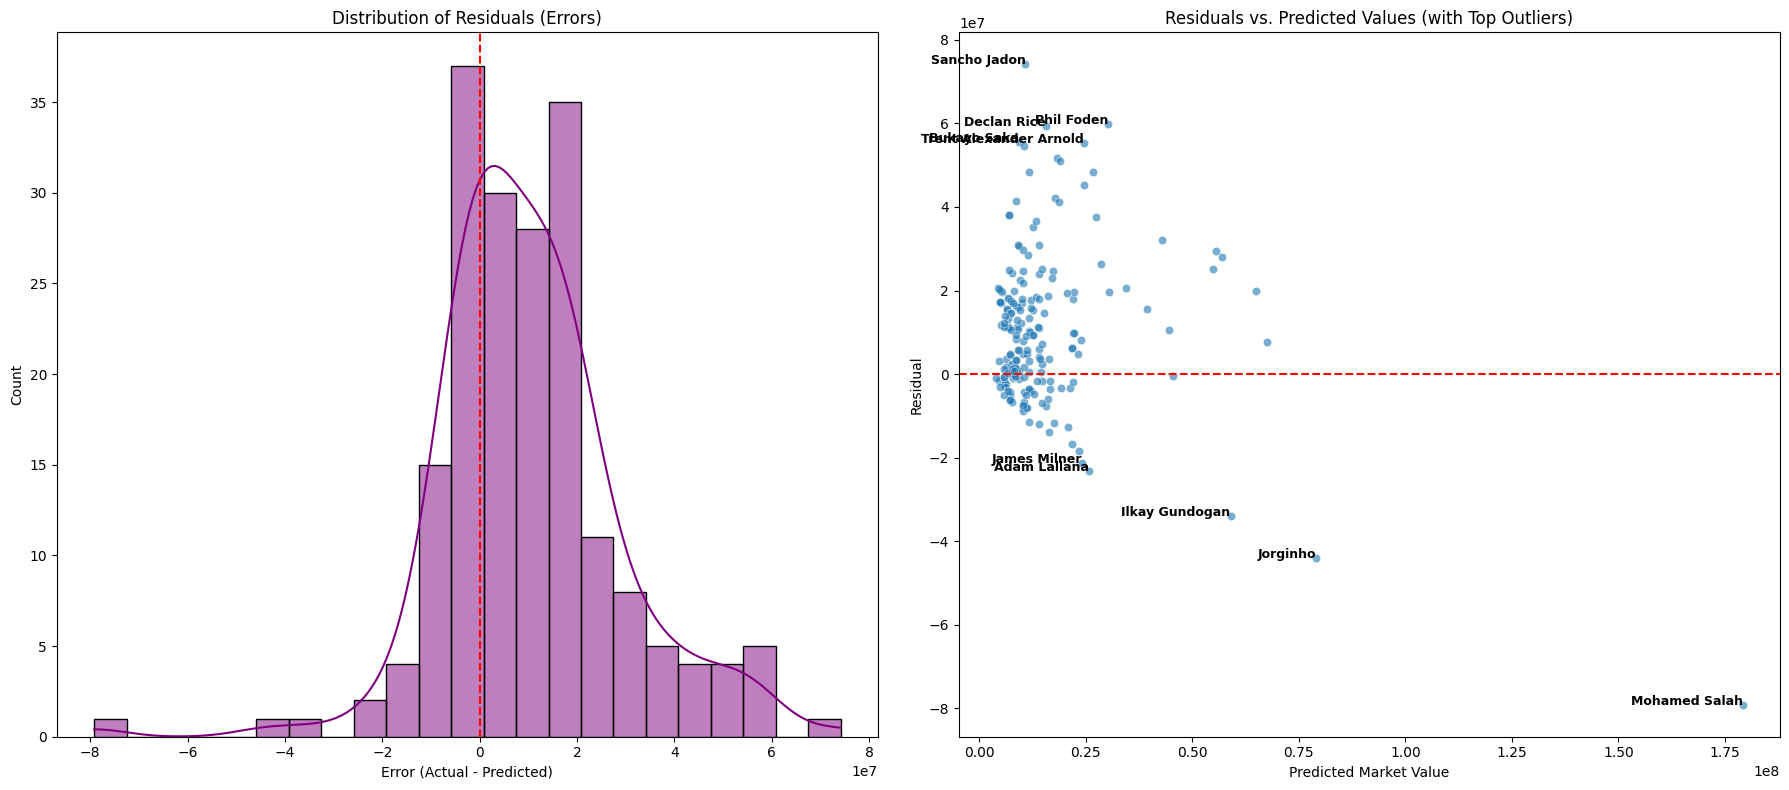

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# residauls
sns.histplot(test_df['Residual_LogModel'], kde=True, ax=axes[0], color='purple')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribution of Residuals (Errors)')
axes[0].set_xlabel('Error (Actual - Predicted)')

# residuals vs predicted
sns.scatterplot(data=test_df, x='Predicted_MV_LogModel', y='Residual_LogModel', alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values (with Top Outliers)')
axes[1].set_xlabel('Predicted Market Value')
axes[1].set_ylabel('Residual')

# 5 most
undervalued = test_df.sort_values(by='Residual_LogModel', ascending=False).head(5)
overvalued = test_df.sort_values(by='Residual_LogModel', ascending=True).head(5)

# labels
for _, row in pd.concat([undervalued, overvalued]).iterrows():
    axes[1].text(
        row['Predicted_MV_LogModel'],
        row['Residual_LogModel'],
        row['Player'],
        fontsize=9,
        fontweight='bold',
        ha='right' if row['Predicted_MV_LogModel'] > test_df['Residual_LogModel'].median() else 'left'
    )

plt.tight_layout()
plt.show()

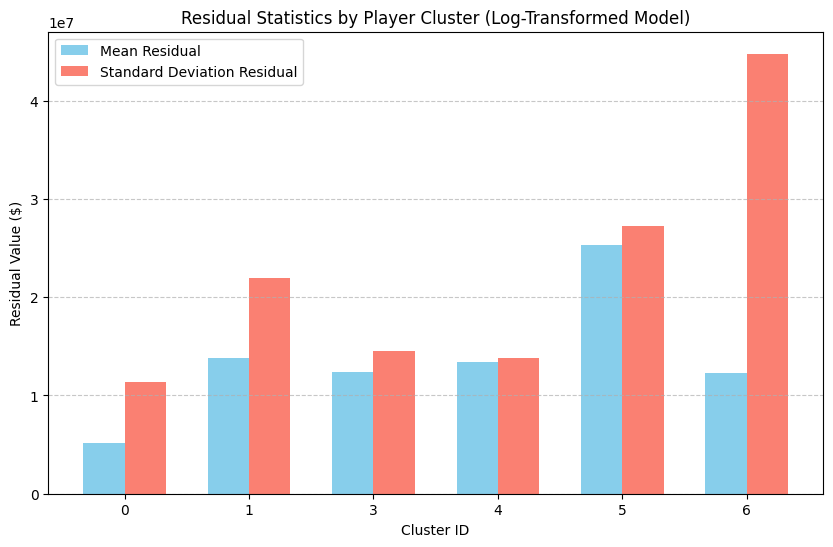

In [99]:


cluster_stats = merged_df.groupby('Cluster')['Residual_LogModel'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cluster_stats['Cluster']))
width = 0.166

ax.bar(x - width, cluster_stats['mean'], 2*width, label='Mean Residual', color='skyblue')
ax.bar(x + width, cluster_stats['std'], 2*width, label='Standard Deviation Residual', color='salmon')
#ax.bar(x + width, cluster_stats['max'], width, label='Max Residual (Undervalued)', color='lightgreen')

ax.set_xlabel('Cluster ID')
ax.set_ylabel('Residual Value ($)')
ax.set_title('Residual Statistics by Player Cluster (Log-Transformed Model)')
ax.set_xticks(x)
ax.set_xticklabels(cluster_stats['Cluster'].astype(int))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()